## Setup

In [ ]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [2]:
import medmnist
from medmnist import INFO, Evaluator

In [11]:
# Import local files
%load_ext autoreload
%autoreload 2
from bcnn_training import *
from cnn_training import get_semi_supervised_labels, SSLDataset
from plots import *
from variational_cnn import *
from constants import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [5]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

## Problem 1: Model Collapses when rho_init is higher, but learns with small rho_init which is basically a point estimate
#### Subproblem: rho doesn't really move from initialization

### Trying BCNN on fully labeled dataset, rho_init = -2.25

In [6]:
def default_setup(lr=0.001, l2_weight=0.0, rho_init=-2.25):
    model = VariationalCNN(n_channels, n_classes, rho_init=rho_init)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

In [23]:
bcnn_model_00, criterion, optimizer = default_setup(lr=0.001, rho_init=-2.25)
for name, param in bcnn_model_00.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")
bcnn_history_00 = train_loop_bcnn_hard_pseudo_label(bcnn_model_00, train_loader, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=1.0, num_samples=10, threshold=0.95)
for name, param in bcnn_model_00.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")

layer1.0.r_w: mean=-2.2500, std=0.0000
layer2.0.r_w: mean=-2.2500, std=0.0000
layer3.0.r_w: mean=-2.2500, std=0.0000
layer4.0.r_w: mean=-2.2500, std=0.0000
layer5.0.r_w: mean=-2.2500, std=0.0000
fc.0.r_w: mean=-2.2500, std=0.0000
fc.3.r_w: mean=-2.2500, std=0.0000
fc.6.r_w: mean=-2.2500, std=0.0000


100%|██████████| 8/8 [00:01<00:00,  4.43it/s]


Epoch 1/20 | Train NLL: 1.3939 | Train KL (avg/batch): 0.9018 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.1540 | Val AUC Macro: 0.5823 | Val AUC Global: 0.8807


100%|██████████| 8/8 [00:01<00:00,  4.44it/s]


Epoch 2/20 | Train NLL: 1.3486 | Train KL (avg/batch): 0.9016 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.1312 | Val AUC Macro: 0.5943 | Val AUC Global: 0.8827


...

Epoch 18/20 | Train NLL: 0.8825 | Train KL (avg/batch): 0.8936 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8896 | Val AUC Macro: 0.8381 | Val AUC Global: 0.9355


100%|██████████| 8/8 [00:01<00:00,  4.32it/s]


Epoch 19/20 | Train NLL: 0.8941 | Train KL (avg/batch): 0.8928 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8747 | Val AUC Macro: 0.8418 | Val AUC Global: 0.9381


100%|██████████| 8/8 [00:01<00:00,  4.30it/s]


Epoch 20/20 | Train NLL: 0.8795 | Train KL (avg/batch): 0.8921 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8937 | Val AUC Macro: 0.8336 | Val AUC Global: 0.9335
layer1.0.r_w: mean=-2.2659, std=0.0256
layer2.0.r_w: mean=-2.2549, std=0.0205
layer3.0.r_w: mean=-2.2442, std=0.0217
layer4.0.r_w: mean=-2.2346, std=0.0197
layer5.0.r_w: mean=-2.2344, std=0.0189
fc.0.r_w: mean=-2.2233, std=0.0304
fc.3.r_w: mean=-2.2290, std=0.0524
fc.6.r_w: mean=-2.2766, std=0.0441


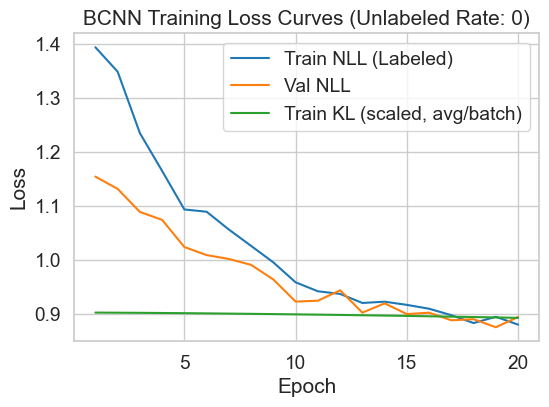

In [24]:
plot_loss_curves_bcnn(bcnn_history_00)

In [25]:
best_bcnn_00_history = max(bcnn_history_00, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_00_history['epoch']} | Val AUC Macro: {best_bcnn_00_history['val_auc_macro']:.4f}")

best_bcnn_model_00 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_00.load_state_dict(best_bcnn_00_history['model_state'])

Best Epoch: 19 | Val AUC Macro: 0.8418


<All keys matched successfully>

In [26]:
test_results_bcnn_00 = evaluate_bayesian(best_bcnn_model_00, test_loader, device='cpu')
test_results_bcnn_00

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.50it/s]

preds: [5 5 5 ... 5 5 5]


{'macro_auc': 0.8369742291563714,
 'global_auc': 0.9367316123655947,
 'nll': np.float32(0.882991),
 'per_class_auc': [0.8621438729741979,
  0.8774769532326728,
  0.8435217723453018,
  0.8540341332865353,
  0.7983119687155561,
  0.8603126151136987,
  0.763018288426637],
 'confusion_matrix': array([[0.        , 0.        , 0.10606061, 0.        , 0.        ,
         0.89393939, 0.        ],
        [0.        , 0.        , 0.08737864, 0.        , 0.        ,
         0.91262136, 0.        ],
        [0.        , 0.00454545, 0.19545455, 0.        , 0.        ,
         0.8       , 0.        ],
        [0.        , 0.        , 0.13043478, 0.        , 0.        ,
         0.86956522, 0.        ],
        [0.        , 0.        , 0.03139013, 0.        , 0.        ,
         0.96860987, 0.        ],
        [0.        , 0.        , 0.00745712, 0.        , 0.        ,
         0.99254288, 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        , 0.

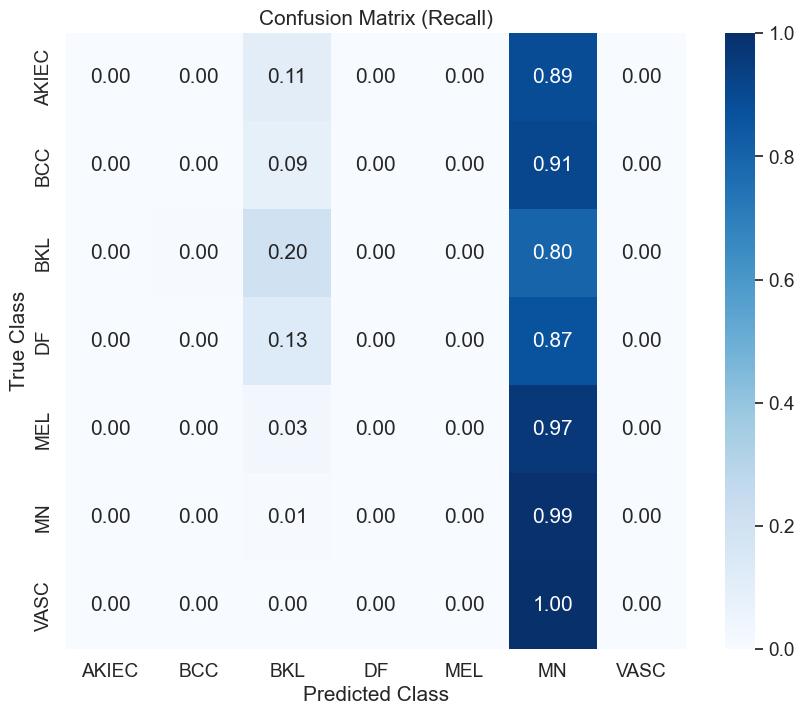

In [27]:
plot_per_class_recall(test_results_bcnn_00['confusion_matrix'], list(short_labels.values()))

#### Result: collapses to majority class prediction

### Reducing the rho_init to -5

In [28]:
bcnn_model_00_2, criterion, optimizer = default_setup(lr=0.001, rho_init=-5.0)
for name, param in bcnn_model_00_2.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")
bcnn_history_00_2 = train_loop_bcnn_hard_pseudo_label(bcnn_model_00_2, train_loader, val_loader, criterion, optimizer, num_epochs=20, alpha=0.5, beta=1.0, num_samples=10, threshold=0.95)
for name, param in bcnn_model_00_2.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")

layer1.0.r_w: mean=-5.0000, std=0.0000
layer2.0.r_w: mean=-5.0000, std=0.0000
layer3.0.r_w: mean=-5.0000, std=0.0000
layer4.0.r_w: mean=-5.0000, std=0.0000
layer5.0.r_w: mean=-5.0000, std=0.0000
fc.0.r_w: mean=-5.0000, std=0.0000
fc.3.r_w: mean=-5.0000, std=0.0000
fc.6.r_w: mean=-5.0000, std=0.0000


100%|██████████| 8/8 [00:01<00:00,  4.52it/s]


Epoch 1/20 | Train NLL: 0.9358 | Train KL (avg/batch): 2.2454 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.8451 | Val AUC Macro: 0.8581 | Val AUC Global: 0.9412


100%|██████████| 8/8 [00:01<00:00,  4.50it/s]


Epoch 2/20 | Train NLL: 0.7938 | Train KL (avg/batch): 2.2381 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 0.7616 | Val AUC Macro: 0.8970 | Val AUC Global: 0.9521


...

Epoch 18/20 | Train NLL: 0.1111 | Train KL (avg/batch): 2.1439 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.0562 | Val AUC Macro: 0.8811 | Val AUC Global: 0.9421


100%|██████████| 8/8 [00:01<00:00,  4.31it/s]


Epoch 19/20 | Train NLL: 0.0920 | Train KL (avg/batch): 2.1397 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.0882 | Val AUC Macro: 0.9006 | Val AUC Global: 0.9473


100%|██████████| 8/8 [00:01<00:00,  4.29it/s]

Epoch 20/20 | Train NLL: 0.0720 | Train KL (avg/batch): 2.1356 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/0 | Val Loss: 1.0583 | Val AUC Macro: 0.8929 | Val AUC Global: 0.9495
layer1.0.r_w: mean=-5.0128, std=0.0551
layer2.0.r_w: mean=-4.9820, std=0.0578
layer3.0.r_w: mean=-4.9184, std=0.0591
layer4.0.r_w: mean=-4.8693, std=0.0598
layer5.0.r_w: mean=-4.8615, std=0.0615
fc.0.r_w: mean=-4.7110, std=0.1820
fc.3.r_w: mean=-4.6796, std=0.2467
fc.6.r_w: mean=-4.8836, std=0.1462


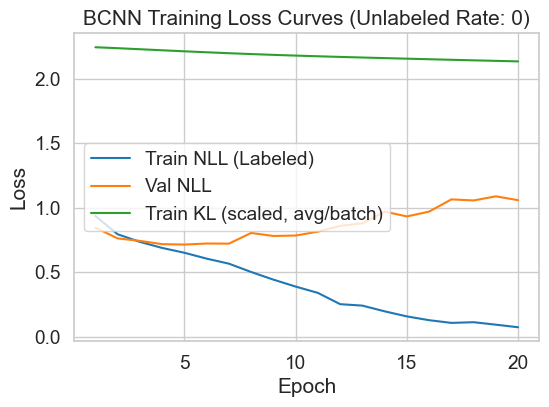

In [29]:
plot_loss_curves_bcnn(bcnn_history_00_2)

In [30]:
best_bcnn_00_2_history = max(bcnn_history_00_2, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_00_2_history['epoch']} | Val AUC Macro: {best_bcnn_00_2_history['val_auc_macro']:.4f}")

best_bcnn_model_00_2 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_00_2.load_state_dict(best_bcnn_00_2_history['model_state'])

Best Epoch: 6 | Val AUC Macro: 0.9199


<All keys matched successfully>

In [31]:
test_results_bcnn_00_2 = evaluate_bayesian(best_bcnn_model_00_2, test_loader, device='cpu')
test_results_bcnn_00_2

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:05<00:00,  1.53it/s]

preds: [5 1 2 ... 5 5 5]


{'macro_auc': 0.9097609972497412,
 'global_auc': 0.9561151982885677,
 'nll': np.float32(0.7280485),
 'per_class_auc': [0.9456452091831153,
  0.9321562381958695,
  0.8743799337916984,
  0.9159829772298513,
  0.8527980351597692,
  0.9055629677546877,
  0.9418016194331983],
 'confusion_matrix': array([[3.93939394e-01, 2.72727273e-01, 1.96969697e-01, 0.00000000e+00,
         1.51515152e-02, 1.21212121e-01, 0.00000000e+00],
        [7.76699029e-02, 5.72815534e-01, 2.33009709e-01, 0.00000000e+00,
         1.94174757e-02, 8.73786408e-02, 9.70873786e-03],
        [3.18181818e-02, 6.81818182e-02, 5.54545455e-01, 0.00000000e+00,
         1.36363636e-02, 3.31818182e-01, 0.00000000e+00],
        [1.73913043e-01, 2.60869565e-01, 2.17391304e-01, 8.69565217e-02,
         0.00000000e+00, 2.60869565e-01, 0.00000000e+00],
        [2.24215247e-02, 4.48430493e-02, 2.24215247e-01, 4.48430493e-03,
         7.62331839e-02, 6.27802691e-01, 0.00000000e+00],
        [1.49142431e-03, 1.93885160e-02, 4.54884415e-

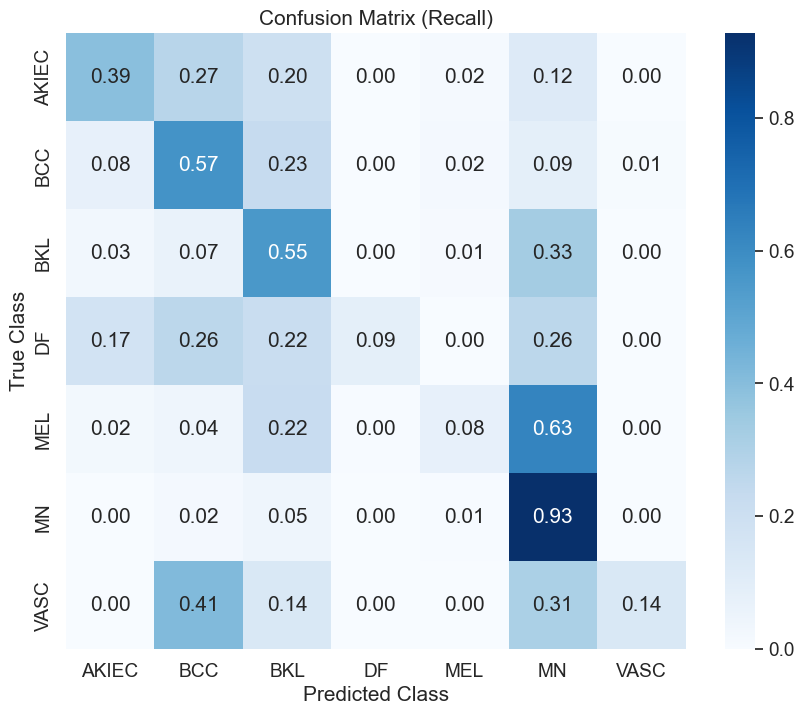

In [32]:
plot_per_class_recall(test_results_bcnn_00_2['confusion_matrix'], list(short_labels.values()))

## Problem 2: Hard PLs reinforce class imbalance in a cycle

In [33]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5
RANDOM_SEED = 42
train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


In [35]:
bcnn_model_50, criterion, optimizer = default_setup(lr=0.001, rho_init=-2.25)
for name, param in bcnn_model_50.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")
bcnn_history_50 = train_loop_bcnn_hard_pseudo_label(bcnn_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=1.0, num_samples=10, threshold=0.95)
for name, param in bcnn_model_50.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")

layer1.0.r_w: mean=-2.2500, std=0.0000
layer2.0.r_w: mean=-2.2500, std=0.0000
layer3.0.r_w: mean=-2.2500, std=0.0000
layer4.0.r_w: mean=-2.2500, std=0.0000
layer5.0.r_w: mean=-2.2500, std=0.0000
fc.0.r_w: mean=-2.2500, std=0.0000
fc.3.r_w: mean=-2.2500, std=0.0000
fc.6.r_w: mean=-2.2500, std=0.0000


100%|██████████| 8/8 [00:01<00:00,  4.37it/s]


Epoch 1/30 | Train NLL: 1.4055 | Train KL (avg/batch): 0.9019 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/3501 | Val Loss: 1.1622 | Val AUC Macro: 0.5221 | Val AUC Global: 0.8732


100%|██████████| 8/8 [00:01<00:00,  4.24it/s]


Epoch 2/30 | Train NLL: 1.2922 | Train KL (avg/batch): 0.9017 | Train Loss Unlabeled: 0.0000 | Unlabeled Examples Used: 0/3501 | Val Loss: 1.1442 | Val AUC Macro: 0.5749 | Val AUC Global: 0.8815


...

Epoch 28/30 | Train NLL: 0.8654 | Train KL (avg/batch): 0.8877 | Train Loss Unlabeled: 0.0650 | Unlabeled Examples Used: 1086/3501 | Val Loss: 0.8973 | Val AUC Macro: 0.8433 | Val AUC Global: 0.9373


100%|██████████| 8/8 [00:01<00:00,  4.45it/s]


Epoch 29/30 | Train NLL: 0.8557 | Train KL (avg/batch): 0.8869 | Train Loss Unlabeled: 0.0587 | Unlabeled Examples Used: 1090/3501 | Val Loss: 0.8949 | Val AUC Macro: 0.8341 | Val AUC Global: 0.9367


100%|██████████| 8/8 [00:01<00:00,  4.42it/s]

Epoch 30/30 | Train NLL: 0.8570 | Train KL (avg/batch): 0.8860 | Train Loss Unlabeled: 0.0449 | Unlabeled Examples Used: 1054/3501 | Val Loss: 0.8773 | Val AUC Macro: 0.8434 | Val AUC Global: 0.9369
layer1.0.r_w: mean=-2.2842, std=0.0435
layer2.0.r_w: mean=-2.2599, std=0.0324
layer3.0.r_w: mean=-2.2446, std=0.0305
layer4.0.r_w: mean=-2.2307, std=0.0284
layer5.0.r_w: mean=-2.2298, std=0.0291
fc.0.r_w: mean=-2.2045, std=0.0450
fc.3.r_w: mean=-2.2113, std=0.0950
fc.6.r_w: mean=-2.2793, std=0.0815


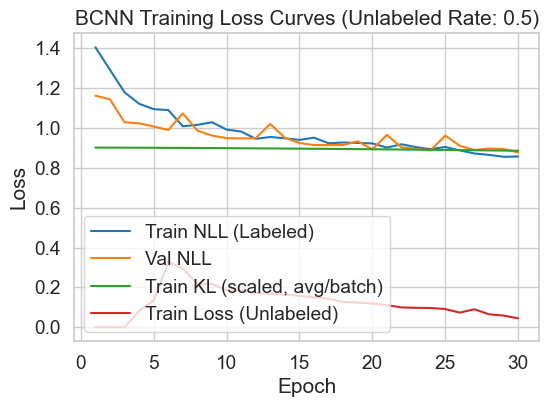

In [36]:
plot_loss_curves_bcnn(bcnn_history_50, unlabeled_rate=0.50, use_unlabeled=True)

In [37]:
best_bcnn_50_history = max(bcnn_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_50_history['epoch']} | Val AUC Macro: {best_bcnn_50_history['val_auc_macro']:.4f}")

best_bcnn_model_50 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_50.load_state_dict(best_bcnn_50_history['model_state'])

Best Epoch: 24 | Val AUC Macro: 0.8437


<All keys matched successfully>

In [38]:
test_results_bcnn_50 = evaluate_bayesian(best_bcnn_model_50, test_loader, device='cpu')
test_results_bcnn_50

100%|██████████| 8/8 [00:05<00:00,  1.56it/s]

preds: [5 5 5 ... 5 5 5]


{'macro_auc': 0.8395843267234382,
 'global_auc': 0.936176889447205,
 'nll': np.float32(0.8936998),
 'per_class_auc': [0.8789676027943176,
  0.8659816442579604,
  0.8397860962566845,
  0.8746764357478174,
  0.7883493630877785,
  0.8498198610998806,
  0.7795092838196287],
 'confusion_matrix': array([[0.        , 0.07575758, 0.01515152, 0.        , 0.        ,
         0.90909091, 0.        ],
        [0.        , 0.03883495, 0.00970874, 0.        , 0.        ,
         0.95145631, 0.        ],
        [0.        , 0.03636364, 0.01818182, 0.        , 0.        ,
         0.94545455, 0.        ],
        [0.        , 0.04347826, 0.04347826, 0.        , 0.        ,
         0.91304348, 0.        ],
        [0.        , 0.0044843 , 0.00896861, 0.        , 0.        ,
         0.98654709, 0.        ],
        [0.        , 0.00149142, 0.00149142, 0.        , 0.        ,
         0.99701715, 0.        ],
        [0.        , 0.03448276, 0.        , 0.        , 0.        ,
         0.96551724, 0

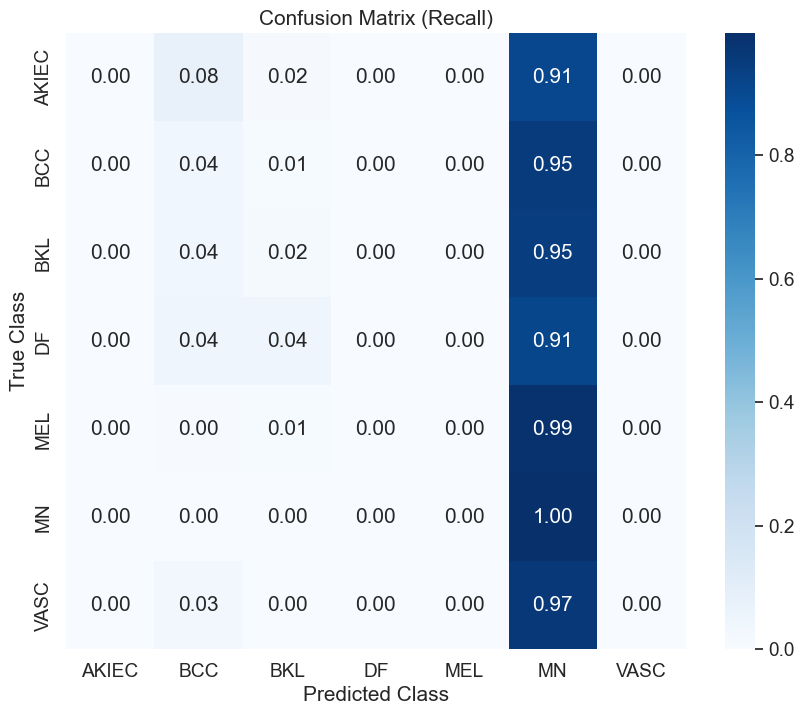

In [39]:
plot_per_class_recall(test_results_bcnn_50['confusion_matrix'], list(short_labels.values()))

In [43]:
with torch.no_grad():
    for threshold in [0.95, 0.80, 0.70, 0.50]:
        all_pseudo_labels = []
        for images, labels in train_ssl_loader_50:
            unlabeled_mask = (labels == -1).squeeze()
            inputs_unlabeled = images[unlabeled_mask]
            if inputs_unlabeled.size(0) > 0:
                avg_probs = best_bcnn_model_50.average_probs(inputs_unlabeled, num_samples=10)
                max_probs, pseudo_labels = torch.max(avg_probs, dim=1)
                confident = max_probs >= threshold
                if confident.sum() > 0:
                    all_pseudo_labels.append(pseudo_labels[confident])

        all_pseudo_labels = torch.cat(all_pseudo_labels)
        print(f"τ={threshold}: {np.round(np.bincount(all_pseudo_labels.numpy(), minlength=7) / len(all_pseudo_labels), 3)} ({len(all_pseudo_labels)} examples)" )

τ=0.95: [0. 0. 0. 0. 0. 1. 0.] (340 examples)
τ=0.8: [0. 0. 0. 0. 0. 1. 0.] (1616 examples)
τ=0.7: [0. 0. 0. 0. 0. 1. 0.] (2372 examples)
τ=0.5: [0. 0. 0. 0. 0. 1. 0.] (3022 examples)


#### So when the model collapses, pseudo labels don't help because the model's output is always majority class

#### So, what if we go back to the other rho -5?

In [44]:
bcnn_model_50_2, criterion, optimizer = default_setup(lr=0.001, rho_init=-5.0)
for name, param in bcnn_model_50_2.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")
bcnn_history_50_2 = train_loop_bcnn_hard_pseudo_label(bcnn_model_50_2, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=1.0, num_samples=10, threshold=0.95)
for name, param in bcnn_model_50_2.named_parameters():
    if 'r_w' in name:
        print(f"{name}: mean={param.data.mean():.4f}, std={param.data.std():.4f}")

layer1.0.r_w: mean=-5.0000, std=0.0000
layer2.0.r_w: mean=-5.0000, std=0.0000
layer3.0.r_w: mean=-5.0000, std=0.0000
layer4.0.r_w: mean=-5.0000, std=0.0000
layer5.0.r_w: mean=-5.0000, std=0.0000
fc.0.r_w: mean=-5.0000, std=0.0000
fc.3.r_w: mean=-5.0000, std=0.0000
fc.6.r_w: mean=-5.0000, std=0.0000


100%|██████████| 8/8 [00:01<00:00,  4.58it/s]


Epoch 1/30 | Train NLL: 0.9497 | Train KL (avg/batch): 2.2460 | Train Loss Unlabeled: 0.1582 | Unlabeled Examples Used: 565/3501 | Val Loss: 0.8558 | Val AUC Macro: 0.8749 | Val AUC Global: 0.9426


100%|██████████| 8/8 [00:01<00:00,  4.54it/s]


Epoch 2/30 | Train NLL: 0.8007 | Train KL (avg/batch): 2.2406 | Train Loss Unlabeled: 0.0912 | Unlabeled Examples Used: 1169/3501 | Val Loss: 0.7975 | Val AUC Macro: 0.8990 | Val AUC Global: 0.9489


...

Epoch 28/30 | Train NLL: 0.0505 | Train KL (avg/batch): 2.1280 | Train Loss Unlabeled: 0.0138 | Unlabeled Examples Used: 2508/3501 | Val Loss: 1.4304 | Val AUC Macro: 0.8628 | Val AUC Global: 0.9334


100%|██████████| 8/8 [00:01<00:00,  4.51it/s]


Epoch 29/30 | Train NLL: 0.0622 | Train KL (avg/batch): 2.1244 | Train Loss Unlabeled: 0.0154 | Unlabeled Examples Used: 2499/3501 | Val Loss: 1.3666 | Val AUC Macro: 0.8772 | Val AUC Global: 0.9401


100%|██████████| 8/8 [00:01<00:00,  4.53it/s]

Epoch 30/30 | Train NLL: 0.0488 | Train KL (avg/batch): 2.1208 | Train Loss Unlabeled: 0.0124 | Unlabeled Examples Used: 2584/3501 | Val Loss: 1.3075 | Val AUC Macro: 0.8719 | Val AUC Global: 0.9410
layer1.0.r_w: mean=-5.0148, std=0.0719
layer2.0.r_w: mean=-4.9872, std=0.0546
layer3.0.r_w: mean=-4.9272, std=0.0584
layer4.0.r_w: mean=-4.8821, std=0.0572
layer5.0.r_w: mean=-4.8777, std=0.0561
fc.0.r_w: mean=-4.6569, std=0.2311
fc.3.r_w: mean=-4.6277, std=0.2977
fc.6.r_w: mean=-4.8750, std=0.1653


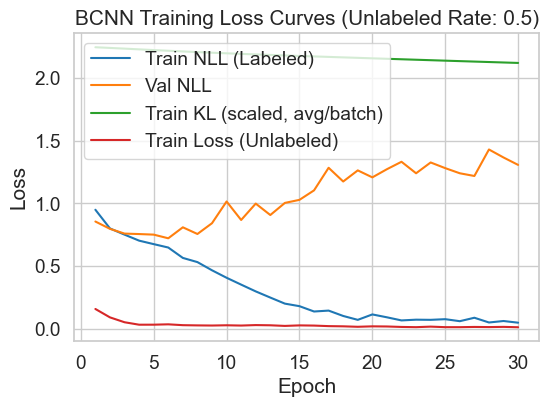

In [45]:
plot_loss_curves_bcnn(bcnn_history_50_2, unlabeled_rate=0.50, use_unlabeled=True)

In [46]:
best_bcnn_50_2_history = max(bcnn_history_50_2, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_bcnn_50_2_history['epoch']} | Val AUC Macro: {best_bcnn_50_2_history['val_auc_macro']:.4f}")

best_bcnn_model_50_2 = VariationalCNN(n_channels, n_classes)
best_bcnn_model_50_2.load_state_dict(best_bcnn_50_2_history['model_state'])

Best Epoch: 6 | Val AUC Macro: 0.9118


<All keys matched successfully>

In [47]:
test_results_bcnn_50_2 = evaluate_bayesian(best_bcnn_model_50_2, test_loader, device='cpu')
test_results_bcnn_50_2

100%|██████████| 8/8 [00:05<00:00,  1.54it/s]

preds: [5 1 2 ... 5 5 5]


{'macro_auc': 0.8985983801402873,
 'global_auc': 0.9554994475573328,
 'nll': np.float32(0.7408074),
 'per_class_auc': [0.9305796489912013,
  0.9207426010433575,
  0.8683626177743825,
  0.8858202079585837,
  0.8291484853517738,
  0.8957766187793681,
  0.9597584810833449],
 'confusion_matrix': array([[3.33333333e-01, 1.66666667e-01, 1.51515152e-01, 0.00000000e+00,
         9.09090909e-02, 2.42424242e-01, 1.51515152e-02],
        [8.73786408e-02, 3.98058252e-01, 1.06796117e-01, 0.00000000e+00,
         5.82524272e-02, 3.10679612e-01, 3.88349515e-02],
        [4.54545455e-02, 5.00000000e-02, 3.27272727e-01, 4.54545455e-03,
         8.63636364e-02, 4.86363636e-01, 0.00000000e+00],
        [1.30434783e-01, 1.73913043e-01, 1.30434783e-01, 0.00000000e+00,
         4.34782609e-02, 4.78260870e-01, 4.34782609e-02],
        [1.79372197e-02, 2.24215247e-02, 1.03139013e-01, 0.00000000e+00,
         2.37668161e-01, 6.14349776e-01, 4.48430493e-03],
        [7.45712155e-04, 1.04399702e-02, 1.26771066e-

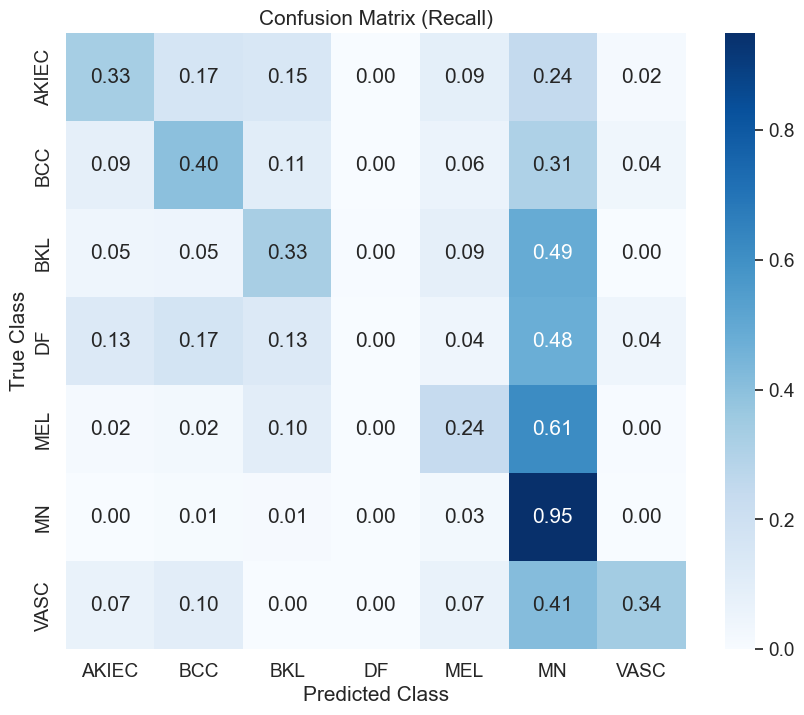

In [48]:
plot_per_class_recall(test_results_bcnn_50_2['confusion_matrix'], list(short_labels.values()))

In [49]:
with torch.no_grad():
    for threshold in [0.95, 0.80, 0.70, 0.50]:
        all_pseudo_labels = []
        for images, labels in train_ssl_loader_50:
            unlabeled_mask = (labels == -1).squeeze()
            inputs_unlabeled = images[unlabeled_mask]
            if inputs_unlabeled.size(0) > 0:
                avg_probs = best_bcnn_model_50_2.average_probs(inputs_unlabeled, num_samples=10)
                max_probs, pseudo_labels = torch.max(avg_probs, dim=1)
                confident = max_probs >= threshold
                if confident.sum() > 0:
                    all_pseudo_labels.append(pseudo_labels[confident])

        all_pseudo_labels = torch.cat(all_pseudo_labels)
        print(f"τ={threshold}: {np.round(np.bincount(all_pseudo_labels.numpy(), minlength=7) / len(all_pseudo_labels), 3)} ({len(all_pseudo_labels)} examples)" )

τ=0.95: [0. 0. 0. 0. 0. 1. 0.] (1268 examples)
τ=0.8: [0.    0.001 0.004 0.    0.001 0.992 0.003] (1935 examples)
τ=0.7: [0.    0.007 0.014 0.    0.006 0.97  0.003] (2295 examples)
τ=0.5: [0.002 0.026 0.039 0.    0.037 0.891 0.006] (2954 examples)


#### Even when we reduce rho_init and the model learns something reasonable, the PLs are increasing the class imbalance issue

## Problem 3: Soft PLs struggle to produce different distributions when rho_init is higher

In [51]:
upgrade_model_50, criterion, optimizer = default_setup(rho_init=-2.25)
upgrade_history_50 = train_loop_bcnn_soft_pseudo_label(upgrade_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=1.0, num_samples=10)

100%|██████████| 8/8 [00:01<00:00,  4.77it/s]


Epoch 1/30 | Train NLL: 1.4744 | Train KL (avg/batch): 0.9019 | Unlabeled Examples Used: 3501/3501 | Val Loss: 1.1684 | Train Loss Unlabeled: 1.5400 | Val AUC Macro: 0.5106 | Val AUC Global: 0.8672


100%|██████████| 8/8 [00:01<00:00,  4.39it/s]


Epoch 2/30 | Train NLL: 1.2920 | Train KL (avg/batch): 0.9017 | Unlabeled Examples Used: 3501/3501 | Val Loss: 1.1536 | Train Loss Unlabeled: 1.3059 | Val AUC Macro: 0.5134 | Val AUC Global: 0.8766


100%|██████████| 8/8 [00:01<00:00,  4.49it/s]


...

Epoch 28/30 | Train NLL: 0.8600 | Train KL (avg/batch): 0.8885 | Unlabeled Examples Used: 3501/3501 | Val Loss: 0.9006 | Train Loss Unlabeled: 0.9233 | Val AUC Macro: 0.8484 | Val AUC Global: 0.9355


100%|██████████| 8/8 [00:01<00:00,  4.50it/s]


Epoch 29/30 | Train NLL: 0.8590 | Train KL (avg/batch): 0.8877 | Unlabeled Examples Used: 3501/3501 | Val Loss: 0.9020 | Train Loss Unlabeled: 0.9260 | Val AUC Macro: 0.8507 | Val AUC Global: 0.9356


100%|██████████| 8/8 [00:01<00:00,  4.52it/s]

Epoch 30/30 | Train NLL: 0.8422 | Train KL (avg/batch): 0.8869 | Unlabeled Examples Used: 3501/3501 | Val Loss: 0.8911 | Train Loss Unlabeled: 0.9385 | Val AUC Macro: 0.8499 | Val AUC Global: 0.9357


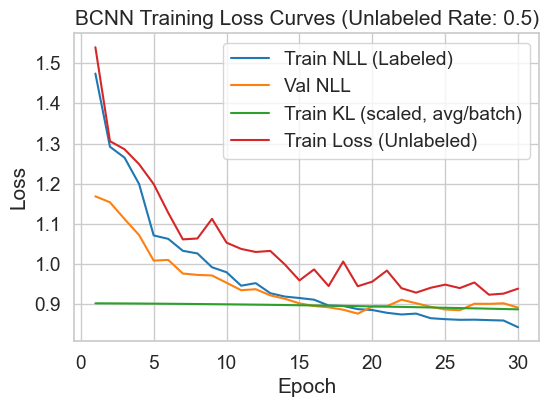

In [52]:
plot_loss_curves_bcnn(upgrade_history_50, unlabeled_rate=0.50, use_unlabeled=True)

In [53]:
best_upgrade_50_history = max(upgrade_history_50, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_50_history['epoch']} | Val AUC Macro: {best_upgrade_50_history['val_auc_macro']:.4f}")

best_upgrade_model_50 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_50.load_state_dict(best_upgrade_50_history['model_state'])

Best Epoch: 29 | Val AUC Macro: 0.8507


<All keys matched successfully>

In [54]:
test_results_upgrade_50 = evaluate_bayesian(best_upgrade_model_50, test_loader, device='cpu')
test_results_upgrade_50

100%|██████████| 8/8 [00:05<00:00,  1.54it/s]

preds: [5 1 2 ... 5 5 5]


{'macro_auc': 0.8424191279614054,
 'global_auc': 0.9372113772095114,
 'nll': np.float32(0.89537),
 'per_class_auc': [0.8676684326503821,
  0.8800189886986616,
  0.8486452762923351,
  0.8624577721230202,
  0.7951890605104357,
  0.8547545888250991,
  0.7881997766299037],
 'confusion_matrix': array([[0.        , 0.10606061, 0.15151515, 0.        , 0.        ,
         0.74242424, 0.        ],
        [0.        , 0.13592233, 0.12621359, 0.        , 0.        ,
         0.73786408, 0.        ],
        [0.        , 0.03636364, 0.21818182, 0.        , 0.        ,
         0.74545455, 0.        ],
        [0.        , 0.2173913 , 0.26086957, 0.        , 0.        ,
         0.52173913, 0.        ],
        [0.        , 0.0044843 , 0.04035874, 0.        , 0.        ,
         0.95515695, 0.        ],
        [0.        , 0.00223714, 0.00820283, 0.        , 0.        ,
         0.98956003, 0.        ],
        [0.        , 0.        , 0.06896552, 0.        , 0.        ,
         0.93103448, 0.

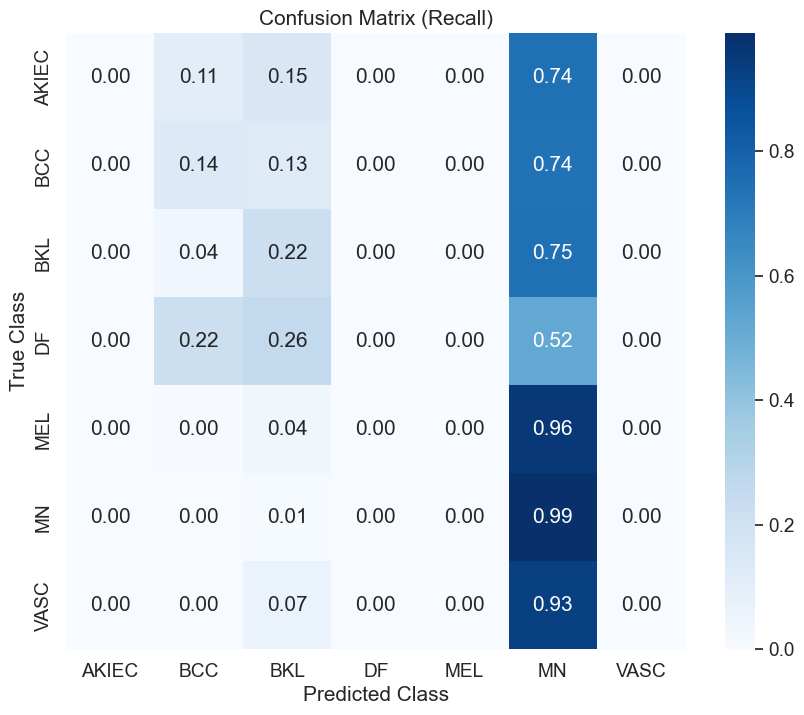

In [55]:
plot_per_class_recall(test_results_upgrade_50['confusion_matrix'], list(short_labels.values()))

In [56]:
# best_upgrade_model_50.eval()
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_loader:
        avg_probs = best_upgrade_model_50.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.099 0.177 0.2   0.04  0.106 0.343 0.035]
Class 1: [0.095 0.18  0.191 0.04  0.102 0.354 0.037]
Class 2: [0.065 0.114 0.202 0.024 0.158 0.414 0.023]
Class 3: [0.103 0.183 0.187 0.043 0.097 0.348 0.038]
Class 4: [0.032 0.056 0.143 0.012 0.188 0.555 0.015]
Class 5: [0.023 0.04  0.084 0.009 0.118 0.709 0.016]
Class 6: [0.054 0.104 0.113 0.025 0.101 0.57  0.032]


#### rho_init = -5?

In [57]:
upgrade_model_50_2, criterion, optimizer = default_setup(rho_init=-5.0)
upgrade_history_50_2 = train_loop_bcnn_soft_pseudo_label(upgrade_model_50_2, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=30, alpha=0.5, beta=1.0, num_samples=10)

100%|██████████| 8/8 [00:01<00:00,  4.68it/s]


Epoch 1/30 | Train NLL: 0.9475 | Train KL (avg/batch): 2.2459 | Unlabeled Examples Used: 3501/3501 | Val Loss: 0.8154 | Train Loss Unlabeled: 0.9406 | Val AUC Macro: 0.8786 | Val AUC Global: 0.9448


100%|██████████| 8/8 [00:01<00:00,  4.68it/s]


Epoch 2/30 | Train NLL: 0.7922 | Train KL (avg/batch): 2.2399 | Unlabeled Examples Used: 3501/3501 | Val Loss: 0.7703 | Train Loss Unlabeled: 0.8105 | Val AUC Macro: 0.9014 | Val AUC Global: 0.9505


100%|██████████| 8/8 [00:01<00:00,  4.45it/s]


...

Epoch 28/30 | Train NLL: 0.0380 | Train KL (avg/batch): 2.1168 | Unlabeled Examples Used: 3501/3501 | Val Loss: 1.1952 | Train Loss Unlabeled: 0.2865 | Val AUC Macro: 0.8920 | Val AUC Global: 0.9480


100%|██████████| 8/8 [00:01<00:00,  4.39it/s]


Epoch 29/30 | Train NLL: 0.0252 | Train KL (avg/batch): 2.1122 | Unlabeled Examples Used: 3501/3501 | Val Loss: 1.3052 | Train Loss Unlabeled: 0.2864 | Val AUC Macro: 0.8930 | Val AUC Global: 0.9407


100%|██████████| 8/8 [00:01<00:00,  4.53it/s]

Epoch 30/30 | Train NLL: 0.0376 | Train KL (avg/batch): 2.1076 | Unlabeled Examples Used: 3501/3501 | Val Loss: 1.2036 | Train Loss Unlabeled: 0.2853 | Val AUC Macro: 0.8852 | Val AUC Global: 0.9460


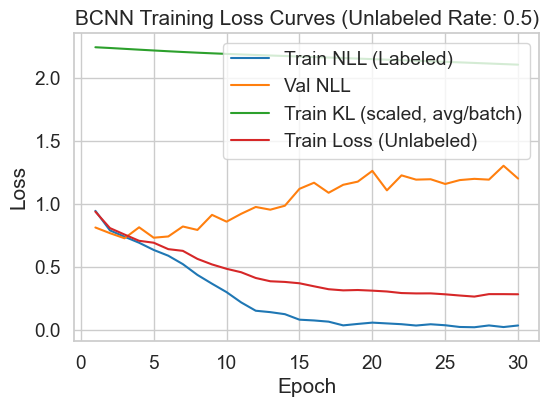

In [58]:
plot_loss_curves_bcnn(upgrade_history_50_2, unlabeled_rate=0.50, use_unlabeled=True)

In [59]:
best_upgrade_50_2_history = max(upgrade_history_50_2, key=lambda x: x['val_auc_macro'])
print(f"Best Epoch: {best_upgrade_50_2_history['epoch']} | Val AUC Macro: {best_upgrade_50_2_history['val_auc_macro']:.4f}")

best_upgrade_model_50_2 = VariationalCNN(n_channels, n_classes)
best_upgrade_model_50_2.load_state_dict(best_upgrade_50_2_history['model_state'])

Best Epoch: 6 | Val AUC Macro: 0.9108


<All keys matched successfully>

In [60]:
test_results_upgrade_50_2 = evaluate_bayesian(best_upgrade_model_50_2, test_loader, device='cpu')
test_results_upgrade_50_2

100%|██████████| 8/8 [00:05<00:00,  1.53it/s]

preds: [5 6 2 ... 5 5 5]


{'macro_auc': 0.8952435534983062,
 'global_auc': 0.954628308696256,
 'nll': np.float32(0.7554585),
 'per_class_auc': [0.9305952771656743,
  0.9114524312680571,
  0.8650903997962822,
  0.8652656517351819,
  0.8495342060364481,
  0.8977824047869329,
  0.9469845036995672],
 'confusion_matrix': array([[1.51515152e-01, 2.87878788e-01, 9.09090909e-02, 0.00000000e+00,
         1.51515152e-01, 2.72727273e-01, 4.54545455e-02],
        [9.70873786e-03, 3.98058252e-01, 8.73786408e-02, 9.70873786e-03,
         6.79611650e-02, 3.30097087e-01, 9.70873786e-02],
        [2.27272727e-02, 5.00000000e-02, 3.22727273e-01, 0.00000000e+00,
         1.45454545e-01, 4.54545455e-01, 4.54545455e-03],
        [0.00000000e+00, 1.73913043e-01, 8.69565217e-02, 0.00000000e+00,
         4.34782609e-02, 6.08695652e-01, 8.69565217e-02],
        [8.96860987e-03, 1.79372197e-02, 6.72645740e-02, 0.00000000e+00,
         2.64573991e-01, 6.27802691e-01, 1.34529148e-02],
        [7.45712155e-04, 1.26771066e-02, 1.34228188e-0

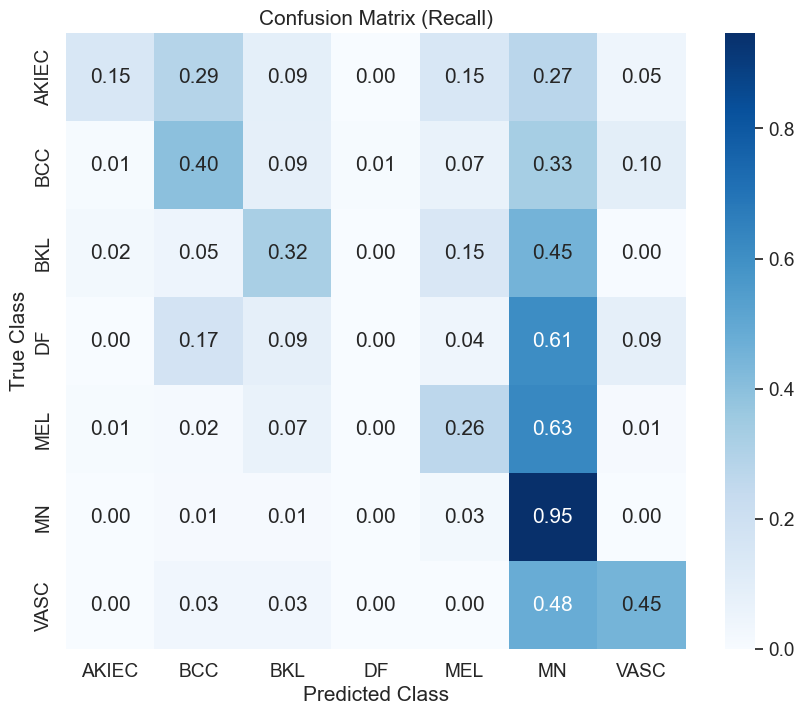

In [61]:
plot_per_class_recall(test_results_upgrade_50_2['confusion_matrix'], list(short_labels.values()))

In [62]:
class_probs = [[] for _ in range(7)]
with torch.no_grad():
    for images, labels in train_loader:
        avg_probs = best_upgrade_model_50_2.average_probs(images, num_samples=10)
        for i in range(7):
            mask = (labels.squeeze() == i)
            if mask.sum() > 0:
                class_probs[i].append(avg_probs[mask])

for i in range(7):
    if class_probs[i]:
        mean_dist = torch.cat(class_probs[i]).mean(dim=0).numpy()
        print(f"Class {i}: {np.round(mean_dist, 3)}")

Class 0: [0.2   0.192 0.163 0.044 0.127 0.231 0.044]
Class 1: [0.074 0.392 0.128 0.027 0.085 0.232 0.063]
Class 2: [0.036 0.054 0.328 0.016 0.155 0.403 0.008]
Class 3: [0.074 0.17  0.132 0.078 0.077 0.401 0.067]
Class 4: [0.018 0.02  0.102 0.004 0.372 0.469 0.015]
Class 5: [0.005 0.011 0.04  0.002 0.066 0.872 0.003]
Class 6: [0.007 0.055 0.027 0.006 0.093 0.324 0.488]


#### So once again, we see that the rho_init has drastic effects on our model performance

## My unanswered question: how do we know what constitutes a "large" rho? oh and why isn't it moving?